<a href="https://colab.research.google.com/github/NeuralithDev/ML/blob/main/FDTP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/Food_Delivery_Time_Prediction .csv")

In [ ]:
print(df.shape)
print(df.columns.tolist())
print(df.dtypes)
df.head()

(200, 15)
['Order_ID', 'Customer_Location', 'Restaurant_Location', 'Distance', 'Weather_Conditions', 'Traffic_Conditions', 'Delivery_Person_Experience', 'Order_Priority', 'Order_Time', 'Vehicle_Type', 'Restaurant_Rating', 'Customer_Rating', 'Delivery_Time', 'Order_Cost', 'Tip_Amount']
Order_ID                       object
Customer_Location              object
Restaurant_Location            object
Distance                      float64
Weather_Conditions             object
Traffic_Conditions             object
Delivery_Person_Experience      int64
Order_Priority                 object
Order_Time                     object
Vehicle_Type                   object
Restaurant_Rating             float64
Customer_Rating               float64
Delivery_Time                 float64
Order_Cost                    float64
Tip_Amount                    float64
dtype: object


,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34


In [ ]:
#count missing values in each column
missing_val = df.isnull().sum()
print(missing_val[missing_val > 0])

Series([], dtype: int64)


In [ ]:
# also check as percentage helpful for deciding drop vs fill
percent_missing = df.isnull().sum() * 100 / len(df)
print(percent_missing)

Order_ID                      0.0
Customer_Location             0.0
Restaurant_Location           0.0
Distance                      0.0
Weather_Conditions            0.0
Traffic_Conditions            0.0
Delivery_Person_Experience    0.0
Order_Priority                0.0
Order_Time                    0.0
Vehicle_Type                  0.0
Restaurant_Rating             0.0
Customer_Rating               0.0
Delivery_Time                 0.0
Order_Cost                    0.0
Tip_Amount                    0.0
dtype: float64


In [ ]:
# fix missing values - Strategy depends on the column type
# for numeric columns -> fill with median (more robust than mean for robust data)
# here there are no missing values but for example if any in other dataset then
df['Distance'].fillna(df['Distance'].mean(), inplace=True)
df['Delivery_Time'].fillna(df['Delivery_Time'].mean(), inplace=True)

#for categorical columns -> fill with the most common value (mode)
df['Weather_Conditions'].fillna(df['Weather_Conditions'].mode()[0] , inplace=True)
df['Traffic_Conditions'].fillna(df['Traffic_Conditions'].mode()[0], inplace=True)

print("Missing values after fix: ", df.isnull().sum())

Missing values after fix:  Order_ID                      0
Customer_Location             0
Restaurant_Location           0
Distance                      0
Weather_Conditions            0
Traffic_Conditions            0
Delivery_Person_Experience    0
Order_Priority                0
Order_Time                    0
Vehicle_Type                  0
Restaurant_Rating             0
Customer_Rating               0
Delivery_Time                 0
Order_Cost                    0
Tip_Amount                    0
dtype: int64


/tmp/ipykernel_798/1487610067.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Distance'].fillna(df['Distance'].mean(), inplace=True)
/tmp/ipykernel_798/1487610067.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

In [ ]:
#Check which columns are categorical
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(categorical_cols)

['Order_ID', 'Customer_Location', 'Restaurant_Location', 'Weather_Conditions', 'Traffic_Conditions', 'Order_Priority', 'Order_Time', 'Vehicle_Type']


Method 1 : Label Encoding -> Converts each category to a number (0,1,2...)

In [ ]:
#Best for columns with 2 values , or where order matters (eg. Low/Medium/High traffic)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Weather_Encoded'] = le.fit_transform(df['Weather_Conditions'])
df['Traffic_Encoded'] = le.fit_transform(df['Traffic_Conditions'])
df['Vehicle_Encoded'] = le.fit_transform(df['Vehicle_Type'])
df['Order_Priority_en'] = le.fit_transform(df['Order_Priority'])

df.head()



,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,Weather_Encoded,Traffic_Encoded,Vehicle_Encoded,Order_Priority_en
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54,1,2,2,2
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02,0,2,2,1
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17,2,2,1,0
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23,0,1,1,2
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34,1,0,1,1


Method 2: One-Hot Encoding - creates a seperate 0/1 column per category

In [ ]:
# Better when there's NO natural order between categories
df = pd.get_dummies(df, columns=['Weather_Conditions','Traffic_Conditions'], drop_first=True)
print("New Shape after one-hot:",df.shape)
df.head()

New Shape after one-hot: (200, 22)


,Order_ID,Customer_Location,Restaurant_Location,Distance,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,...,Tip_Amount,Weather_Encoded,Traffic_Encoded,Vehicle_Encoded,Order_Priority_en,Weather_Conditions_Rainy,Weather_Conditions_Snowy,Weather_Conditions_Sunny,Traffic_Conditions_Low,Traffic_Conditions_Medium
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,4,Medium,Afternoon,Car,4.1,3.0,...,81.54,1,2,2,2,True,False,False,False,True
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,8,Low,Night,Car,4.5,4.2,...,29.02,0,2,2,1,False,False,False,False,True
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,9,High,Night,Bike,3.3,3.4,...,64.17,2,2,1,0,False,True,False,False,True
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,2,Medium,Evening,Bike,3.2,3.7,...,79.23,0,1,1,2,False,False,False,True,False
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,6,Low,Night,Bike,3.5,2.8,...,2.34,1,0,1,1,True,False,False,False,False


Normalise/Standardise numeric columns

In [ ]:
from sklearn.preprocessing import StandardScaler
# Identify numeric columns to scale
num_cols = ['Distance','Order_Cost','Delivery_Time']

#StandardScaler: makes mean=0 and std=1 -> best for Linear/Logistic Regression
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])
print("After scaling - mean should be ~0 and , std should be ~1: ")
print(df[num_cols].describe().round(2))


After scaling - mean should be ~0 and , std should be ~1: 
       Distance  Order_Cost  Delivery_Time
count    200.00      200.00         200.00
mean      -0.00       -0.00           0.00
std        1.00        1.00           1.00
min       -1.61       -1.69          -1.86
25%       -0.79       -0.90          -0.79
50%       -0.18       -0.02           0.08
75%        0.73        0.91           0.88
max        1.96        1.74           1.65


Final Check before moving to Exploratory Data Analysis

In [ ]:
print("Final Dataset Shape: ", df.shape)
print("\n Any missing values left? ",df.isnull().sum().sum())
print("\nSample of cleaned data: ")
df.head()

Final Dataset Shape:  (200, 22)

 Any missing values left?  0

Sample of cleaned data: 


,Order_ID,Customer_Location,Restaurant_Location,Distance,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,...,Tip_Amount,Weather_Encoded,Traffic_Encoded,Vehicle_Encoded,Order_Priority_en,Weather_Conditions_Rainy,Weather_Conditions_Snowy,Weather_Conditions_Sunny,Traffic_Conditions_Low,Traffic_Conditions_Medium
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",-1.454738,4,Medium,Afternoon,Car,4.1,3.0,...,81.54,1,2,2,2,True,False,False,False,True
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",1.439192,8,Low,Night,Car,4.5,4.2,...,29.02,0,2,2,1,False,False,False,False,True
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",-0.666417,9,High,Night,Bike,3.3,3.4,...,64.17,2,2,1,0,False,True,False,False,True
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",0.335835,2,Medium,Evening,Bike,3.2,3.7,...,79.23,0,1,1,2,False,False,False,True,False
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",-0.700119,6,Low,Night,Bike,3.5,2.8,...,2.34,1,0,1,1,True,False,False,False,False


In [ ]:
for col in df.select_dtypes(include='object').columns:
  print(f"\n{col} - {df[col].nunique()} unique values")
  print(df[col].value_counts().head(5))


Order_ID - 200 unique values
Order_ID
ORD0001    1
ORD0002    1
ORD0003    1
ORD0004    1
ORD0005    1
Name: count, dtype: int64

Customer_Location - 200 unique values
Customer_Location
(17.030479, 79.743077)    1
(15.398319, 86.639122)    1
(15.687342, 83.888808)    1
(20.415599, 78.046984)    1
(14.786904, 78.706532)    1
Name: count, dtype: int64

Restaurant_Location - 200 unique values
Restaurant_Location
(12.358515, 85.100083)    1
(14.174874, 77.025606)    1
(19.594748, 82.048482)    1
(16.915906, 78.278698)    1
(15.206038, 86.203182)    1
Name: count, dtype: int64

Order_Priority - 3 unique values
Order_Priority
Low       75
Medium    67
High      58
Name: count, dtype: int64

Order_Time - 4 unique values
Order_Time
Afternoon    59
Evening      57
Night        45
Morning      39
Name: count, dtype: int64

Vehicle_Type - 3 unique values
Vehicle_Type
Bike       69
Bicycle    69
Car        62
Name: count, dtype: int64


In [ ]:
id_cols = ["Order_ID"]
df.drop(columns=id_cols,inplace=True)
print(df.shape)

(200, 21)


In [ ]:
df.select_dtypes(include='object').columns.tolist()

['Customer_Location',
 'Restaurant_Location',
 'Order_Priority',
 'Order_Time',
 'Vehicle_Type']

In [ ]:
cols_to_drop = ['Customer_Location',
 'Restaurant_Location',
 'Order_Priority',
 'Order_Time',
 'Vehicle_Type']
df.drop(columns= cols_to_drop,inplace=True)

In [ ]:
df.shape

(200, 16)

In [ ]:
df.dtypes

,0
Distance,float64
Delivery_Person_Experience,int64
Restaurant_Rating,float64
Customer_Rating,float64
Delivery_Time,float64
Order_Cost,float64
Tip_Amount,float64
Weather_Encoded,int64
Traffic_Encoded,int64
Vehicle_Encoded,int64


STEP 2: EDA
Cell 1 - Descriptive Statistics

In [ ]:
#Summary stats for every numeric column
df.describe().round(2)

,Distance,Delivery_Person_Experience,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,Weather_Encoded,Traffic_Encoded,Vehicle_Encoded,Order_Priority_en
count,200.00,200.00,200.00,200.00,200.00,200.00,200.00,200.00,200.00,200.00,200.00
mean,-0.00,5.25,3.74,3.69,0.00,-0.00,46.62,1.56,1.08,0.96,1.04
std,1.00,2.75,0.70,0.70,1.00,1.00,29.36,1.10,0.77,0.81,0.79
min,-1.61,1.00,2.50,2.60,-1.86,-1.69,1.24,0.00,0.00,0.00,0.00
25%,-0.79,3.00,3.20,3.10,-0.79,-0.90,21.60,1.00,0.00,0.00,0.00
50%,-0.18,5.00,3.80,3.70,0.08,-0.02,47.53,2.00,1.00,1.00,1.00
75%,0.73,8.00,4.30,4.30,0.88,0.91,70.24,3.00,2.00,2.00,2.00
max,1.96,10.00,5.00,5.00,1.65,1.74,99.74,3.00,2.00,2.00,2.00


In [ ]:
# Look at these 4 things for each column:
# mean vs median (50%) - if very different , data is skewed
# min and max - do they make sense? (eg negative dist = data error)
# std - how spread out are values ?
print("Mean Delivery Time: ", df['Delivery_Time'].mean().round(2))
print("Median delivery time: ", df['Delivery_Time'].median())
print("Fastest delivery:" , df['Delivery_Time'].min())
print("Slowest delivery:", df['Delivery_Time'].max())

Mean Delivery Time:  0.0
Median delivery time:  0.07662482028384994
Fastest delivery: -1.8572692974916925
Slowest delivery: 1.6526082185475406


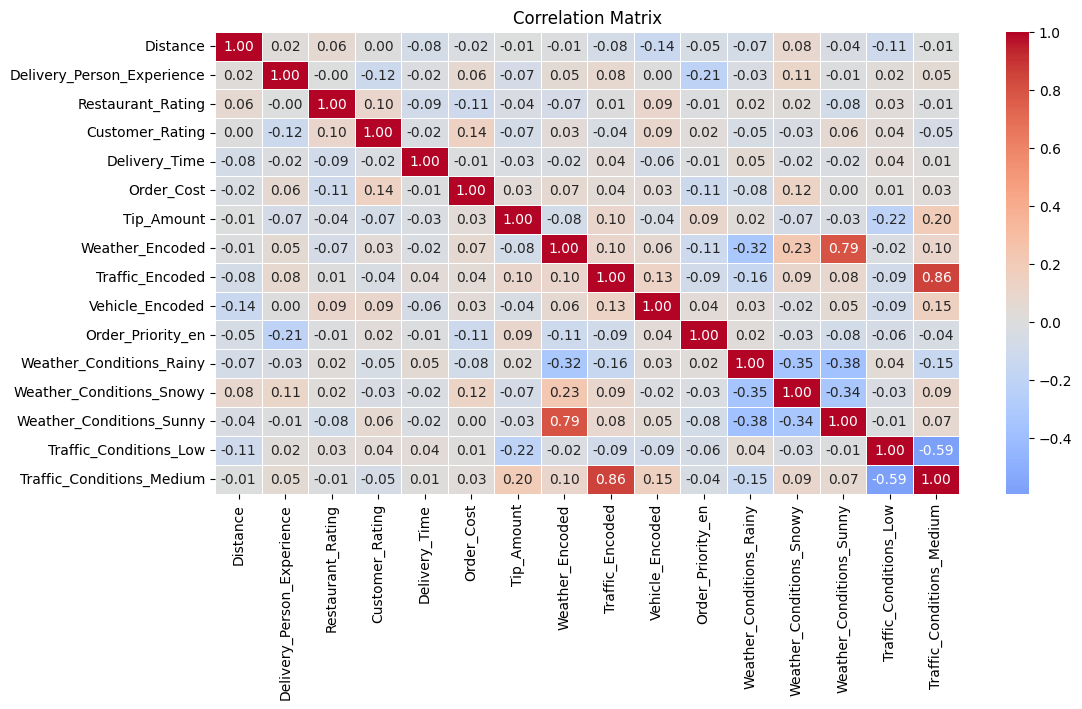

In [ ]:
plt.figure(figsize=(12,6))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True,fmt='.2f',center=0,linewidths=0.5, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
#Now focus specifically on what correlates with your TARGET variable
target_corr = df.corr()['Delivery_Time'].drop('Delivery_Time').sort_values(ascending=False)
print(target_corr.round(3))

Weather_Conditions_Rainy      0.054
Traffic_Encoded               0.040
Traffic_Conditions_Low        0.040
Traffic_Conditions_Medium     0.012
Order_Cost                   -0.009
Order_Priority_en            -0.013
Delivery_Person_Experience   -0.019
Weather_Conditions_Sunny     -0.020
Weather_Encoded              -0.022
Customer_Rating              -0.022
Weather_Conditions_Snowy     -0.025
Tip_Amount                   -0.029
Vehicle_Encoded              -0.056
Distance                     -0.075
Restaurant_Rating            -0.092
Name: Delivery_Time, dtype: float64


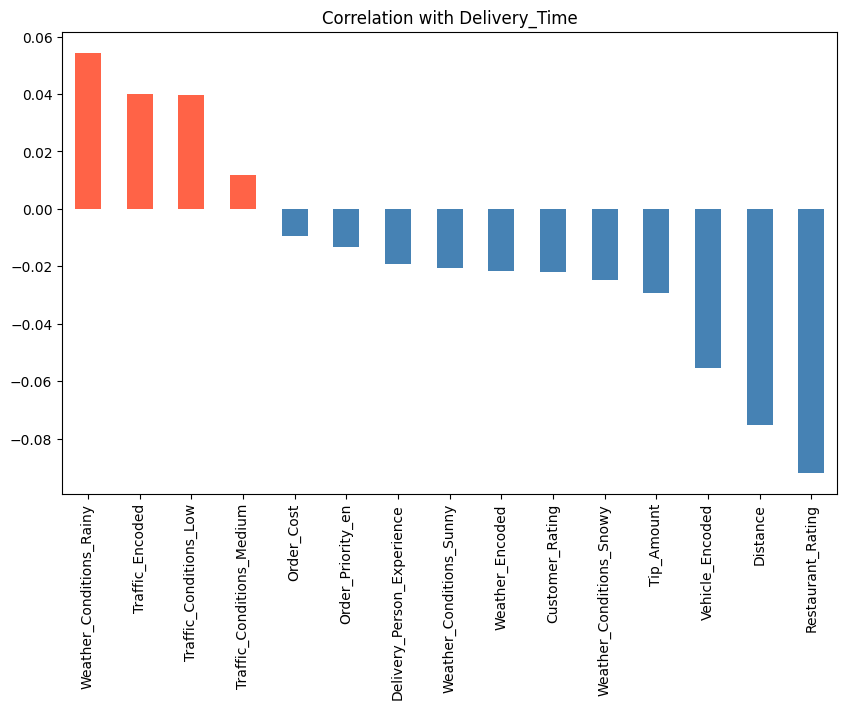

In [ ]:
# visualise it as a bar chart
plt.figure(figsize=(10,6))
target_corr.plot(kind='bar', color=['tomato' if x > 0 else 'steelblue' for x in target_corr])
plt.title('Correlation with Delivery_Time')
plt.show()

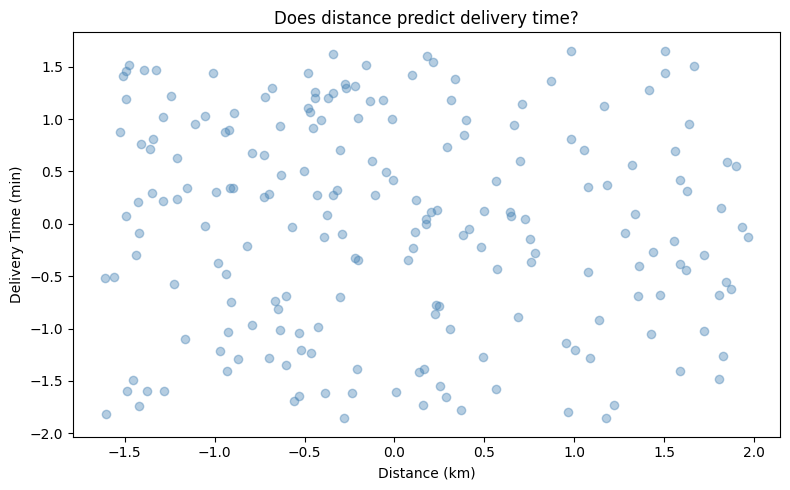

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Distance'], df['Delivery_Time'], alpha=0.4, color='steelblue')
plt.xlabel('Distance (km)')
plt.ylabel('Delivery Time (min)')
plt.title('Does distance predict delivery time?')
plt.tight_layout()
plt.show()

In [ ]:
X = df.drop(columns = ['Delivery_Time'])
y = df['Delivery_Time']
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(X.shape)
print(y.shape)


(200, 15)
(200,)


In [ ]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [ ]:
y_pred = lr.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R-squared: {r2:.2f}")

MAE: 0.92
MSE: 1.16
RMSE: 1.08
R-squared: -0.11


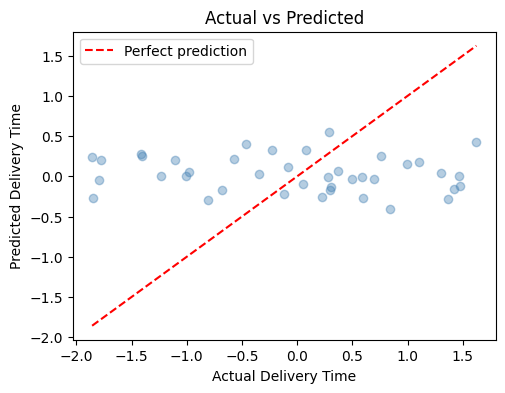

In [ ]:
plt.figure(figsize=(12, 4))

# Plot 1 — Actual vs Predicted scatter
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.4, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=1.5, label='Perfect prediction')
plt.xlabel('Actual Delivery Time')
plt.ylabel('Predicted Delivery Time')
plt.title('Actual vs Predicted')
plt.legend()